In [1]:
try:
    import catboost as cgb
except:
    %pip install -q catboost
    import catboost as cgb

In [2]:
!pip show catboost

Name: catboost
Version: 1.2.10
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, RocCurveDisplay
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder, label_binarize

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [7]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [8]:
train.describe() 

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,690088.000000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,1.025969,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,0.375035,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,0.000000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,1.000000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,1.000000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,1.000000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,2.000000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


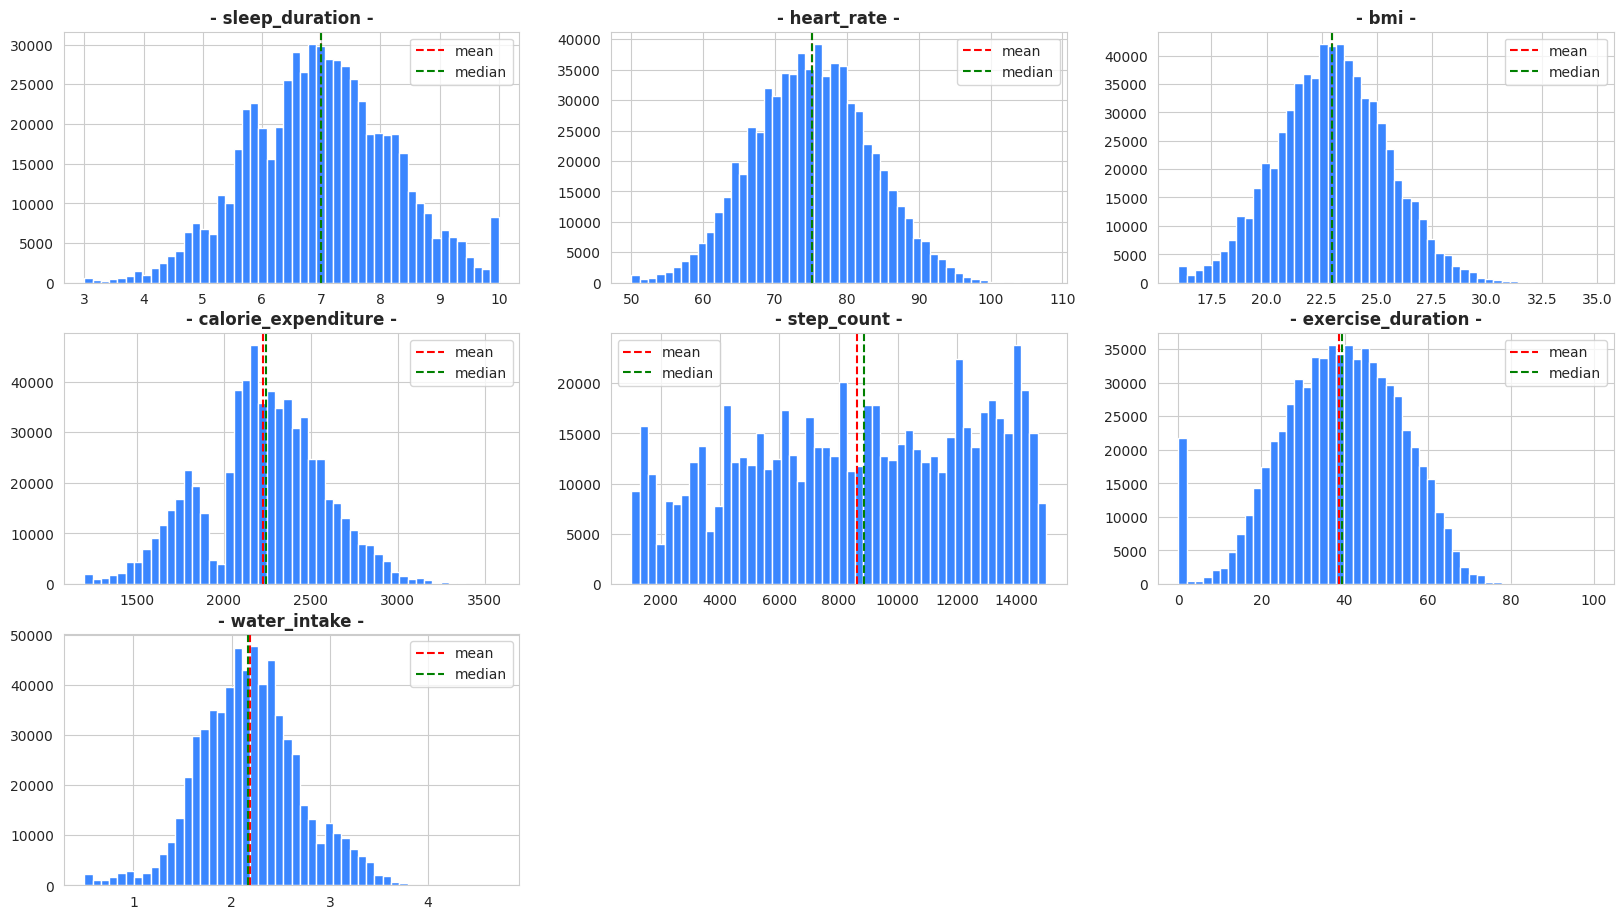

In [9]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()
    
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


## FEATURE ENGINEERING

In [11]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    weights_ = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return weights_

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [12]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories):
    for c in categories:
        X[c] = X[c].factorize()[0]
        X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
    
    ## -- Compute Model Importances --
    print(' • Training base model... ', end='')
    model.fit(
        X_train, y_train,
        # sample_weight=get_sample_weights(y_train, y_train),
    )

    score = balanced_acc(y_test, model.predict_proba(X_test))
    print("Complete!", end='')
    print(f" • Balanced_Accuracy: {score:.5f}")

    model_importances = pd.Series(model.feature_importances_, index=X.columns)

    ## -- Compute Permutation Importances --
    print(' • Training permutation... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=5, # max_samples=0.8,
        # sample_weight=get_sample_weights(y_test, y_test),
        scoring='balanced_accuracy',
        random_state=0, n_jobs=-1,
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(15, len(model_importances)*0.5))
    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")

    axs[1].boxplot(
        result.importances[perm_sorted_idx].T, orientation='horizontal',
        tick_labels=X.columns[perm_sorted_idx], whis=(0, 100),
    )
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle("Impurity-based vs. permutation importances on validation data")
    _ = fig.tight_layout()

print('Plot function script ready!')

Plot function script ready!


 • Training base model... Complete! • Balanced_Accuracy: 0.94678
 • Training permutation... Complete!
CPU times: user 41 s, sys: 9.03 s, total: 50 s
Wall time: 45.9 s


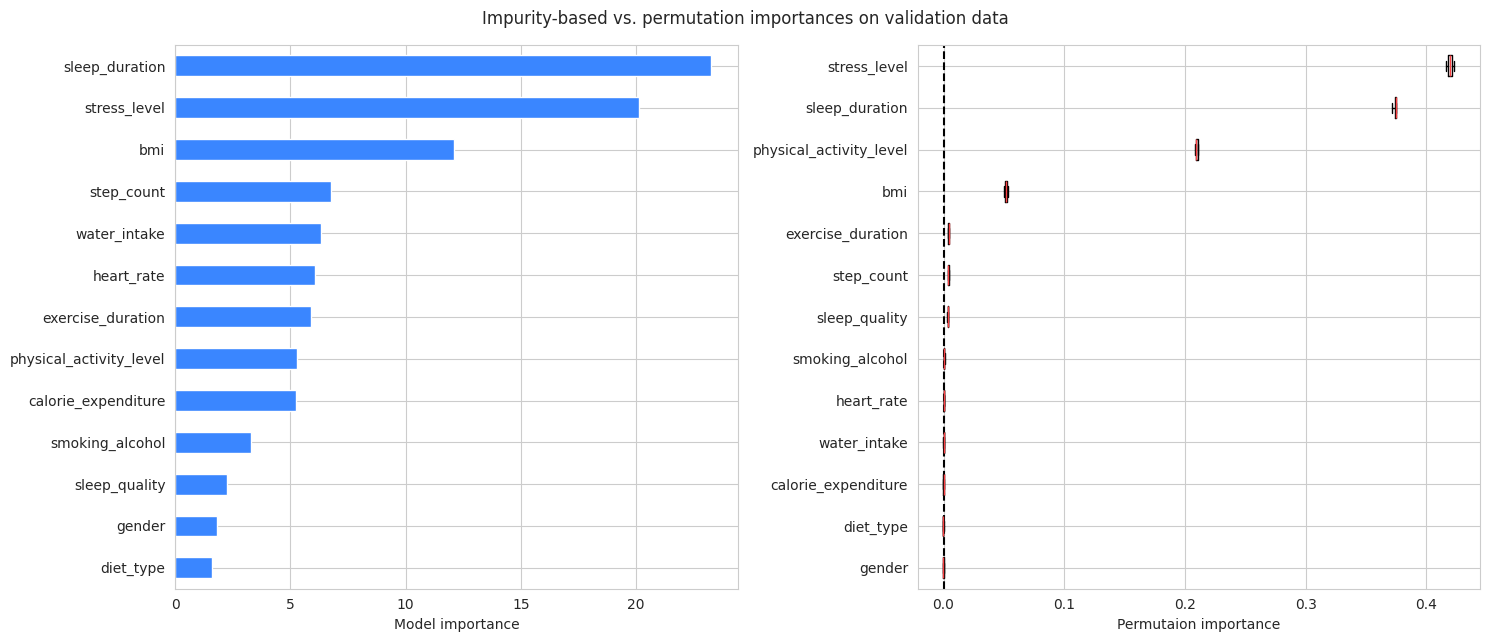

In [13]:
%%time

_model = cgb.CatBoostClassifier(**{
    'loss_function': 'MultiClass',
    'eval_metric': 'MultiClass',
    'auto_class_weights': 'Balanced',
    'classes_count': NUM_CLASSES,
    'cat_features': CATS,
    'random_state': CFG['SEED'],
    'verbose': False,
    'allow_writing_files': False,
    'thread_count': -1,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
})

plot_permutation_importance(_model, train[BASE], train[TARGET], CATS)

In [14]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_valid = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train.loc[:, new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_valid.loc[:, new_col] = opt_multi_b.transform(x_valid[col].to_numpy(), metric=metric)
#         x_test.loc[:, new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

# print('Binning function ready')

In [15]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='cp', # 'cp', 'mip', 'lr'
#     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100, 
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [16]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Optimal Binned Features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [17]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [18]:
# BIN_TABLES[0].analysis()

In [19]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [20]:
# for col in ['alpha', 'delta', 'redshift']:
#     print(f"\nRounding... ", end='')
#     for r in range(-3, 6):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(-3, 7):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nQuantile binning... ", end='')
#     # for q in [32, 64, 128]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [21]:
# for col in ['delta']: # 'u', 'g', 'r', 'i', 'z',
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 5):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)
    
#     # print(f"\nExtracting digits... ", end='')
#     # for d in range(-3, 6):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [100]: # 50, 100, 400
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     # Fit on train data and transform both train and test
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)
        
#     print(f"\nQuantile binning.. ", end='')
#     for q in [90, 180, 360]: 
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [22]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [23]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()

#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# for df in [train, test, orig]:
#     df = add_frequency_condition(df, DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [24]:
# ## -- Arithmetic interaction --

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']
#     df['u_z_sub_'] = df['u'] - df['z']
    
#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_div_{band}_redshift"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [25]:
# ## -- Cyclic encoding --
# for df in tqdm([train, test, orig]):
#     for col in ['alpha', 'delta']:
#         for p in [180, 360]:
#             df[f"_{col}_sin_{p}"] = np.sin(2 * np.pi * df[col] / p).astype('float32')
#             df[f"_{col}_cos_{p}"] = np.cos(2 * np.pi * df[col] / p).astype('float32')

In [26]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [27]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
# #     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
# #     n_col = f"_Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total interaction features: {len(INTER)}")

# train[INTER].head()

In [28]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [30]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [31]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Total original features: {len(ORIG_COLS)}")

In [32]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [33]:
## -- Factorize using combined data --
for c in tqdm(CATS): 
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[len(train)+len(test):]

print('Label encoding complete!')

  0%|          | 0/6 [00:00<?, ?it/s]

Label encoding complete!


In [34]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 13


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0,0,0,0,0,0
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1,1,0,1,0,1
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0,0,1,2,0,2


In [35]:
# _ = [c for c in train.columns if c.startswith("_")]+[TARGET]

# plt.figure(figsize=(18, 12))
# sns.heatmap(train[_].corr("spearman"), annot=True, fmt='.2f', cbar=False)
# plt.tight_layout()
# plt.show()

# ML TRAINING

In [36]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

print()
!pip show venn_abers

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.

Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [37]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold,
               cat_cols=None, use_weights=False, calibrate=False,
               early_stop=50, print_every=200):

    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    X = train_df[features]
    y = train_df[target]

    num_cls = y.nunique()
    
    oof_preds  = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))

    fold_scores  = []
    brier_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n***** FOLD {idx}/{kfold.n_splits} | Calibrate: {str(calibrate)} | ", end="")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # print(f"CategoryMeanEncoding: {len(cats)}")
        # cm_enc  = CategoryMeanTransformer(cat_cols=cats)
        # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
        # X_valid   = cm_enc.transform(X_valid).fillna(-1)
        # X_test  = cm_enc.transform(X_test).fillna(-1)

        # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
        #     x_tr=X_train,
        #     y_tr=y_train,
        #     x_vl=X_valid,
        #     x_ts=X_test,
        #     bin_features=NUMS,
        #     solver='cp', # 'cp', 'mip', 'lr'
        #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
        #     pre_bins=100, 
        #     # period=300,
        # )

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cats:
        #     combined[c] = combined[c].astype(str)
        # X_train = combined.iloc[:len(X_train)]
        # X_valid   = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]


        # ## -- Target Encoding -- 
        # te_cols = ROUNDS # + DIGITS #+ OPT_COLS #+ CATS_2
        # print(f" • Target Encoding {len(te_cols)} features... ")
        # X_train, X_valid, X_test = t_enc_multi(
        #     X_train, X_valid, X_test, y_train, te_cols, drop=False
        # )
        if calibrate:
            print(f" • Training base model {X_train.shape}... ")

            model = cgb.CatBoostClassifier(**params, cat_features=cat_cols)

            print(f"Train shape: {X_train.shape}")
            print(f" • Training model... ")
            model.fit(
                X_train, y_train,
                eval_set=[(X_valid, y_valid)],
                early_stopping_rounds=early_stop, verbose=print_every,
                sample_weight=get_sample_weights(y_train, y_train) if use_weights else None,
            )
            
            feat_importances.append(model.get_feature_importance(prettified=True))
            
            base_acc   = balanced_acc(y_valid, model.predict_proba(X_valid))
            base_brier = multi_class_brier(y_valid, model.predict_proba(X_valid), [*mapping.values()])

            ## -- Calibrate outputs --
            print(f" • Calibrating (venn-abers) {X_calib.shape}... ")
            vao = VennAbersCalibrator() # - Get OOF predictions -
            venn_oof_preds = vao.predict_proba(
                p_cal   = model.predict_proba(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict_proba(X_valid),
                va_type = 'one_vs_all',
            )
            oof_preds[val_idx] = venn_oof_preds

            vat = VennAbersCalibrator() # - Get TEST predictions -
            venn_test_preds = vat.predict_proba(
                p_cal   = model.predict_proba(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict_proba(X_test),
                va_type = 'one_vs_all',
            )

            test_preds += venn_test_preds

            ## -- Fold scores --
            fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], [*mapping.values()])
            fold_scores.append(fold_score); brier_scores.append(brier_score)
            
            print(f"{CFG['YELLOW']}Fold {idx}")
            print(f"base_acc:  {base_acc:.5f} | base_brier:  {base_brier:.5f}")
            print(f"calib_acc: {fold_score:.5f} | calib_brier: {brier_score:.5f}")
            print(f"{CFG['RESET']}")
        ## ====================================================================================
        else:
            model = cgb.CatBoostClassifier(**params, cat_features=cat_cols)
            print(f"Training {model_name} model {X_train.shape}... ")

            print(f" • Training model... ")
            model.fit(
                X_train, y_train,
                eval_set=[(X_valid, y_valid)],
                early_stopping_rounds=early_stop, verbose=print_every,
                sample_weight=get_sample_weights(y_train, y_train) if use_weights else None,
            )

            feat_importances.append(model.get_feature_importance(prettified=True))

            ## -- Predict on val and test sets --
            oof_preds[val_idx] = model.predict_proba(X_valid)
            test_preds += model.predict_proba(X_test)
    
            ## -- Calculate and print fold score --
            fold_score = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], [*mapping.values()])
            fold_scores.append(fold_score); brier_scores.append(brier_score)

            print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
        ## ------------------------------------------------------------------------------------

    ## -- Average test predictions --
    test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'scores': oof_score,
        'models': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [38]:
# !rm -r /kaggle/working/

In [39]:
VERS = 'cat_'
all_predictions = {}

ALL_CATS = CATS
MULTI_SEEDS = [CFG['SEED'], 777, 1234, 24611, 0]

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

skf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [40]:
USE_FULL_TRAIN = True
USE_CALIBRATOR = False

x_sample, x_sample2 = train_test_split(train, train_size=0.1, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0,0,0,0,0,0
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1,1,0,1,0,1
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0,0,1,2,0,2
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0,0,0,2,1,0
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0,-1,0,0,-1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,1,0,1,2,0,0
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,0,2,0,1,2,2
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,1,-1,0,2,2,2
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,2,-1,0,2,0,2


In [41]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_predictions:
#     all_predictions.clear()

# tri_ = "_"

# OUT_LOOP = [0]
# INN_LOOP = [0]
# p_name   = ["l2", "-"]

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # ========================= BAYESIAN
#             # 'grow_policy': "SymmetricTree",
#             # 'bootstrap_type': "Bayesian",
#             # 'bagging_temperature': 0.2,
#             # 'random_strength': 1.0,
#             # ========================= BERNOULLI
#             # 'boosting_type': "Plain",
#             # 'grow_policy': "Depthwise",
#             # 'bootstrap_type': "Bernoulli",
#             # 'subsample': 0.8, # auto 0.66
#             # 'colsample_bylevel': 0.8, # CPU only
#             # 'min_data_in_leaf': 1,
#             # ========================= LOSSGUIDE
#             'boosting_type': "Plain",
#             'grow_policy': "Lossguide",
#             # 'colsample_bylevel': outer,
#             'max_leaves': 63,
#             'min_data_in_leaf': 1,
#             # =================================
#             # 'n_estimators': 300,
#             'loss_function': "MultiClass",
#             'eval_metric': "MultiClass",
#             'classes_count': NUM_CLASSES,
#             'auto_class_weights': 'Balanced',
#             'learning_rate': 0.1, # 0.08
#             # 'depth': 6,
#             'l2_leaf_reg': 2.0,
#             'random_state': CFG['SEED'],
#             'verbose': 0,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'task_type': "GPU" if torch.cuda.is_available() else "CPU",
#         }

#         n = tri_ + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train_data,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kfold=skf,
#             cat_cols=ALL_CATS,
#             calibrate=USE_CALIBRATOR,
#             use_weights=False,
#             early_stop=100,
#             print_every=200,
#         )

# print(f"\n=== Results ready for {len(all_predictions)} model(s) ===\n")

In [42]:
# OOF score: 0.9493
# AVG score: 0.9493 ± 0.00121
# -------------------------------------------------|
# OOF brier: 0.09531
# AVG brier: 0.09531 ± 0.00110
# -------------------------------------------------|
# 0.88 mins

In [43]:
# 5-FOLD CV: Bayesian
# ==================================================
# temp=0.2, rand=1.0, lr=0.08, depth=5, l2=1.0
# ==================================================
#  • Fold 1 score: 0.94994 | brier: 0.09489
#  • Fold 2 score: 0.95146 | brier: 0.09477
#  • Fold 3 score: 0.94897 | brier: 0.09710
#  • Fold 4 score: 0.94883 | brier: 0.09460
#  • Fold 5 score: 0.94738 | brier: 0.09568
# -------------------------------------------------|
# OOF score: 0.94932
# AVG score: 0.94932 ± 0.00135
# -------------------------------------------------|
# OOF brier: 0.09541
# AVG brier: 0.09541 ± 0.00092
# -------------------------------------------------|
# 1.24 mins

# 5-FOLD CV: Bernoulli
# ==================================================
# sub=0.8, lr=0.06, depth=6, leaf=1, l2=1.0
# ==================================================
#  • Fold 1 score: 0.95009 | brier: 0.09341
#  • Fold 2 score: 0.95131 | brier: 0.09375
#  • Fold 3 score: 0.94917 | brier: 0.09554
#  • Fold 4 score: 0.94876 | brier: 0.09270
#  • Fold 5 score: 0.94747 | brier: 0.09376
# -------------------------------------------------|
# OOF score: 0.94936
# AVG score: 0.94936 ± 0.00129
# -------------------------------------------------|
# OOF brier: 0.09383
# AVG brier: 0.09383 ± 0.00094
# -------------------------------------------------|
# 0.91 mins

# 5-FOLD CV: Lossguide
# ==================================================
# leaves=63, lr=0.1, depth=-, leaf=1, l2=2.0
# ==================================================
#  • Fold 1 score: 0.94976 | brier: 0.09758
#  • Fold 2 score: 0.95404 | brier: 0.09837
#  • Fold 3 score: 0.94729 | brier: 0.09834
#  • Fold 4 score: 0.95074 | brier: 0.10045
#  • Fold 5 score: 0.94614 | brier: 0.09460
# -------------------------------------------------|
# OOF score: 0.9493
# AVG score: 0.9493 ± 0.00121
# -------------------------------------------------|
# OOF brier: 0.09531
# AVG brier: 0.09531 ± 0.00110
# -------------------------------------------------|
# 0.88 mins

In [44]:
# all_scores = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == "scores":
#             all_scores[k] = y

# plt.figure(figsize=(16, 5))
# ax1 = sns.lineplot([*all_scores.values()], marker="o")

# y_add = 1e-6

# for i, score in enumerate([*all_scores.values()]):
#     ax1.text(i, score+y_add, score, ha="center", va="baseline", color="b")

# # plt.ylim((0.94, 0.955))
# plt.legend(loc="best")
# plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=90)
# plt.title("Model vs Calibrated", fontdict={"weight": "semibold", "size": 15})

# plt.tight_layout() 
# plt.show()

In [45]:
# all_feat_importances = {}
# all_val_data = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == "importances":
#             all_feat_importances[k] = y # np.mean(value, axis=0)
#         elif x == "val_data":
#             all_val_data[k] = y # -> [0] select X_valid, [1] select y_valid

# top_n = 25

# for i, (k, df) in enumerate(all_feat_importances.items()):
#     df_merge = df[0].merge(df[1], how="left", on="Feature Id", suffixes=("_0", ""))\
#                     .merge(df[2], how="left", on="Feature Id", suffixes=("_1", ""))\
#                     .merge(df[3], how="left", on="Feature Id", suffixes=("_2", "3"))\
#                     # .merge(df[4], how="left", on="Feature Id", suffixes=("_3", "_4"))

#     # display(df_merge.head())
#     ## -------------------------------------------------------------------------------
#     # df_merge["avg_score"] = df_merge.iloc[:, 1:].mean(axis=1)
#     # df_merge.sort_values(by="avg_score").iloc[:, :top_n].plot.barh(y="avg_score", x="Feature Id", figsize=(18, 8))
#     # plt.tight_layout()
#     # plt.show()
#     # print()
#     ## -------------------------------------------------------------------------------
#     df_final = pd.concat([df[0]["Feature Id"], df_merge.drop(columns=["Feature Id"])\
#                                                        .mean(axis=1)], axis=1)\
#                                                        .rename(columns={0: "score"})\
#                                                        .sort_values(by="score")

#     ax = df_final.tail(top_n).plot.barh(y="score", x="Feature Id", figsize=(18, 8))
#     ax.set_title(f"Avg. {CFG['FOLDS']}-Fold feature importances: {k}", fontweight="semibold")
#     plt.tight_layout()
#     plt.show()
#     print()

In [46]:
FUNCTION   = "MultiClass"
METRIC     = "MultiClass"

ITERATIONS  = 1000
EARLY_STOP  = 100
PRINT_EVERY = 100

In [47]:
## =========================== BAYESIAN 
# temp=0.2, rand=0.8, lr=0.08, depth=5, l2=1.0

PARAMS = {
    'boosting_type': "Plain",
    'grow_policy': "SymmetricTree",
    'bootstrap_type': "Bayesian",
    'bagging_temperature': 0.2,
    'random_strength': 1.0,
    # ---------------------------------
    # 'iterations': ITERATIONS,
    'loss_function': FUNCTION,
    'eval_metric': METRIC,
    'classes_count': NUM_CLASSES,
    'auto_class_weights': "Balanced",
    'learning_rate': 0.08,
    'depth': 5,
    'l2_leaf_reg': 1.0,
    # 'one_hot_max_size': 5,
    'random_state': CFG['SEED'],
    'verbose': 0,
    'allow_writing_files': False,
    'thread_count': -1,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = f"{VERS}bayes_calib" if USE_CALIBRATOR else f"{VERS}bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    calibrate=USE_CALIBRATOR,
    early_stop=EARLY_STOP,
    print_every=PRINT_EVERY,
)



===== Starting CV: cat_bayes =====

***** FOLD 1/5 | Calibrate: False | Training cat_bayes model (552070, 13)... 
 • Training model... 
0:	learn: 1.0209984	test: 1.0209693	best: 1.0209693 (0)	total: 19.6ms	remaining: 19.5s
100:	learn: 0.1850960	test: 0.1834589	best: 0.1834589 (100)	total: 1.32s	remaining: 11.8s
200:	learn: 0.1750539	test: 0.1754975	best: 0.1754975 (200)	total: 2.48s	remaining: 9.88s
300:	learn: 0.1708187	test: 0.1735351	best: 0.1735351 (300)	total: 3.6s	remaining: 8.35s
400:	learn: 0.1675370	test: 0.1726961	best: 0.1726872 (394)	total: 4.71s	remaining: 7.04s
500:	learn: 0.1648690	test: 0.1722450	best: 0.1722449 (499)	total: 5.83s	remaining: 5.8s
600:	learn: 0.1623758	test: 0.1718811	best: 0.1718732 (599)	total: 6.96s	remaining: 4.62s
700:	learn: 0.1599933	test: 0.1716875	best: 0.1716583 (695)	total: 8.07s	remaining: 3.44s
800:	learn: 0.1576166	test: 0.1715606	best: 0.1715275 (773)	total: 9.18s	remaining: 2.28s
900:	learn: 0.1554392	test: 0.1715606	best: 0.1714943 (828

In [48]:
## ========================== BERNOULLI
# sub=0.8, lr=0.06, depth=6, leaf= -, l2= -

PARAMS = {
    'boosting_type': "Plain",
    # ---------------------------------
    'grow_policy': "Depthwise",
    # ---------------------------------
    'bootstrap_type': "Bernoulli",
    'subsample': 0.8, # auto 0.66
    # 'colsample_bylevel': 0.8, # CPU only
    # 'min_data_in_leaf': 1,
    # ---------------------------------
    # 'iterations': ITERATIONS,
    'loss_function': FUNCTION,
    'eval_metric': METRIC,
    'classes_count': NUM_CLASSES,
    'auto_class_weights': 'Balanced',
    'learning_rate': 0.06,
    'depth': 6,
    # 'l2_leaf_reg': 1.0,
    # 'one_hot_max_size': 5,
    'random_state': CFG['SEED'],
    'verbose': 0,
    'allow_writing_files': False,
    'thread_count': -1,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = f"{VERS}bern_calib" if USE_CALIBRATOR else f"{VERS}bern"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    calibrate=USE_CALIBRATOR,
    early_stop=EARLY_STOP,
    print_every=PRINT_EVERY,
)


===== Starting CV: cat_bern =====

***** FOLD 1/5 | Calibrate: False | Training cat_bern model (552070, 13)... 
 • Training model... 
0:	learn: 0.9982709	test: 0.9981980	best: 0.9981980 (0)	total: 27.6ms	remaining: 27.6s
100:	learn: 0.1696887	test: 0.1743536	best: 0.1743536 (100)	total: 1.53s	remaining: 13.6s
200:	learn: 0.1587247	test: 0.1720655	best: 0.1720534 (199)	total: 2.86s	remaining: 11.4s
300:	learn: 0.1514970	test: 0.1718025	best: 0.1717118 (277)	total: 4.11s	remaining: 9.55s
400:	learn: 0.1444182	test: 0.1719521	best: 0.1716958 (337)	total: 5.38s	remaining: 8.04s
bestTest = 0.1716958414
bestIteration = 337
Shrink model to first 338 iterations.
Fold 1 acc: 0.94980 | brier: 0.09336

***** FOLD 2/5 | Calibrate: False | Training cat_bern model (552070, 13)... 
 • Training model... 
0:	learn: 0.9983551	test: 0.9981147	best: 0.9981147 (0)	total: 22.7ms	remaining: 22.7s
100:	learn: 0.1703494	test: 0.1714202	best: 0.1714202 (100)	total: 1.54s	remaining: 13.7s
200:	learn: 0.1595975	

In [49]:
## ========================== LOSSGUIDE
# leaves=63, leaf=1, lr=0.1, depth=-, l2=2.0

PARAMS = {
    'boosting_type': "Plain",
    'grow_policy': "Lossguide",
    'max_leaves': 63,
    'min_data_in_leaf': 1,
    # ---------------------------------
    # 'iterations': ITERATIONS,
    'loss_function': FUNCTION,
    'classes_count': NUM_CLASSES,
    'eval_metric': METRIC,
    'auto_class_weights': 'Balanced',
    'learning_rate': 0.1,
    # 'depth': 5,
    'l2_leaf_reg': 2.0,
    # 'one_hot_max_size': 5,
    'random_state': CFG['SEED'],
    'verbose': 0,
    'allow_writing_files': False,
    'thread_count': -1,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = f"{VERS}loss_calib" if USE_CALIBRATOR else f"{VERS}loss"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    calibrate=USE_CALIBRATOR,
    early_stop=EARLY_STOP,
    print_every=PRINT_EVERY,
)


===== Starting CV: cat_loss =====

***** FOLD 1/5 | Calibrate: False | Training cat_loss model (552070, 13)... 
 • Training model... 
0:	learn: 0.9350001	test: 0.9348416	best: 0.9348416 (0)	total: 41.4ms	remaining: 41.4s
100:	learn: 0.1644398	test: 0.1730745	best: 0.1730745 (100)	total: 3.45s	remaining: 30.7s
200:	learn: 0.1521004	test: 0.1721649	best: 0.1721514 (198)	total: 6.48s	remaining: 25.8s
bestTest = 0.1721513571
bestIteration = 198
Shrink model to first 199 iterations.
Fold 1 acc: 0.94979 | brier: 0.09411

***** FOLD 2/5 | Calibrate: False | Training cat_loss model (552070, 13)... 
 • Training model... 
0:	learn: 0.9351649	test: 0.9347607	best: 0.9347607 (0)	total: 41.3ms	remaining: 41.3s
100:	learn: 0.1651379	test: 0.1698484	best: 0.1698382 (99)	total: 3.44s	remaining: 30.7s
200:	learn: 0.1532688	test: 0.1688286	best: 0.1688010 (190)	total: 6.81s	remaining: 27.1s
300:	learn: 0.1435226	test: 0.1691706	best: 0.1687858 (212)	total: 10.1s	remaining: 23.4s
bestTest = 0.1687858438

In [50]:
# ## =========== MVS (only binary) ==============
# PARAMS = {
#     # 'boosting_type': "Plain",
#     # ---------------------------------
#     'grow_policy': "Depthwise",
#     # ---------------------------------
#     'bootstrap_type': "MVS",
#     # 'min_data_in_leaf': 50,
#     'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     'iterations': ITERATIONS,
#     'loss_function': FUNCTION,
#     'eval_metric': METRIC,
#     'learning_rate': LR,
#     'auto_class_weights': CLASS_WEIGHT,
#     # 'depth': 6,
#     'l2_leaf_reg': L2_REG,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'thread_count': os.cpu_count(),
#     'allow_writing_files': False,
#     'task_type': "GPU" if torch.cuda.is_available() else "CPU",
# }

# n = f"{VERS}mvs_calib" if USE_CALIBRATOR else f"{VERS}mvs"

# all_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train_data,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     calibrate=USE_CALIBRATOR,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_EVERY,
# )

In [51]:
# ## ============================ ORDERED BAYESIAN (only binary)

# PARAMS = {
#     'boosting_type': 'Ordered',
#     # ---------------------------------
#     'grow_policy': 'SymmetricTree',
#     # ---------------------------------
#     'bootstrap_type': 'Bayesian',
#     'bagging_temperature': 0.5,
#     # 'random_sampling': 0.8,
#     # ---------------------------------
#     'iterations': ITERATIONS,
#     'loss_function': FUNCTION,
#     'eval_metric': METRIC,
#     'learning_rate': LR,
#     'auto_class_weights': CLASS_WEIGHT,
#     'depth': DEPTH,
#     # 'l2_leaf_reg': L2_REG,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'allow_writing_files': False,
#     'thread_count': os.cpu_count(),
#     'task_type': "GPU" if torch.cuda.is_available() else "CPU",
# }

# n = f"{VERS}ordered_calib" if USE_CALIBRATOR else f"{VERS}ordered"

# all_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train_data,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     calibrate=USE_CALIBRATOR,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_EVERY,
# )

In [52]:
all_predictions.keys()

dict_keys(['cat_bayes', 'cat_bern', 'cat_loss'])

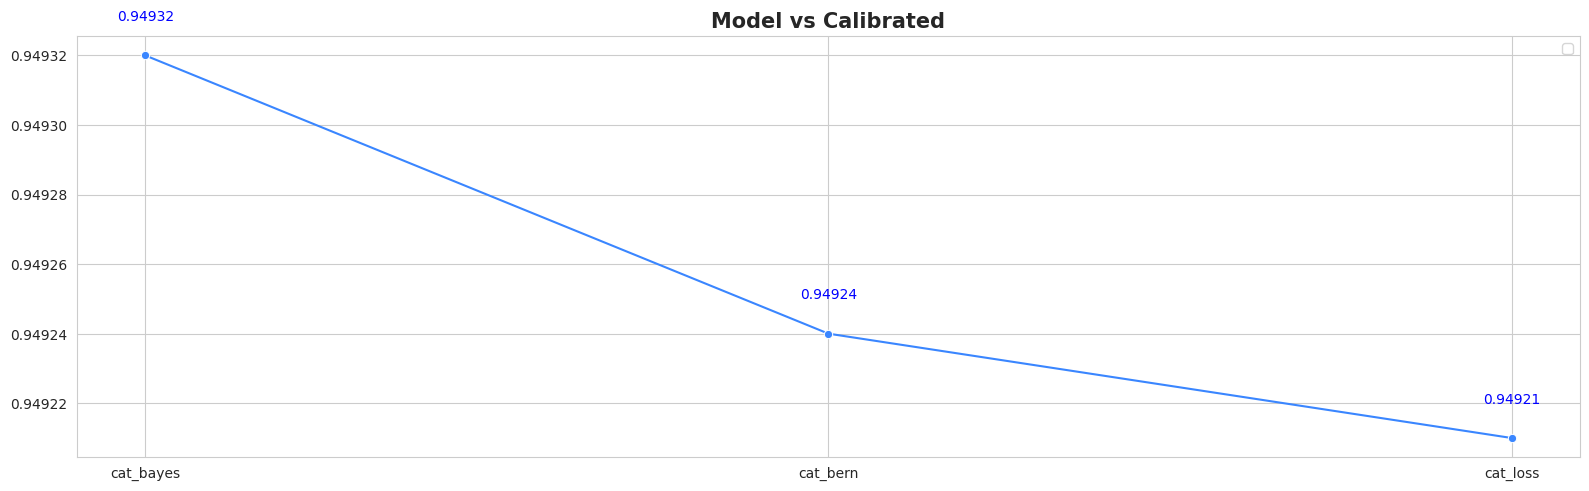

In [53]:
## -- Get model scores --
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "scores":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot([*all_scores.values()], marker="o")

y_add = 1e-5

for i, score in enumerate([*all_scores.values()]):
    ax1.text(i, score+y_add, score, ha="center", va="baseline", color="b")

# plt.ylim((0.94, 0.955))
plt.legend(loc="best")
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title("Model vs Calibrated", fontdict={"weight": "semibold", "size": 15})

plt.tight_layout() 
plt.show()

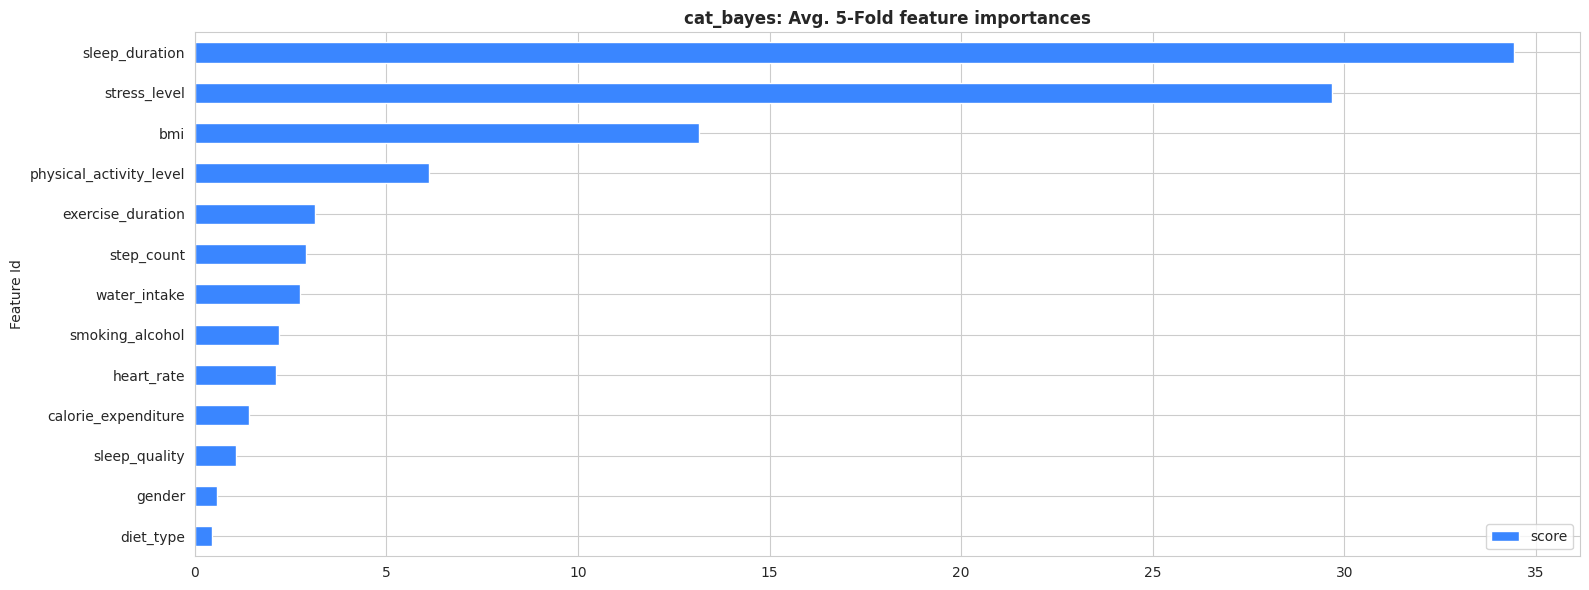

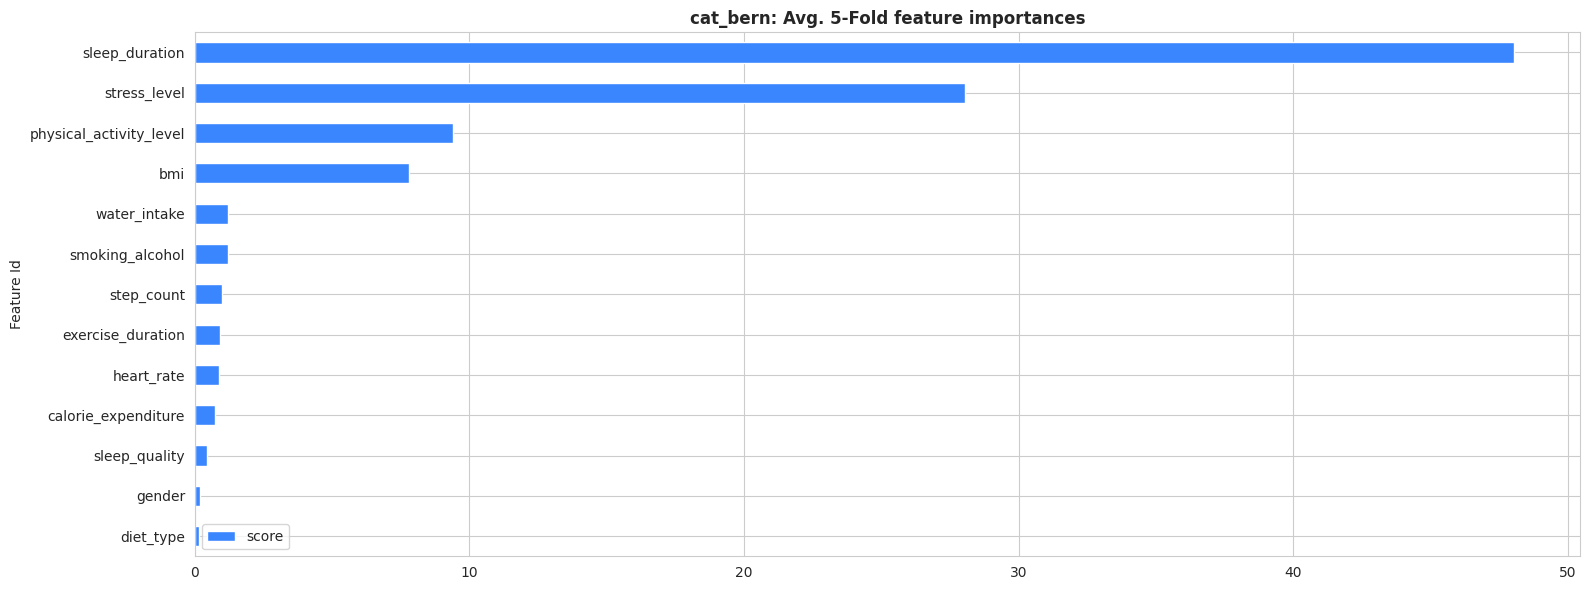

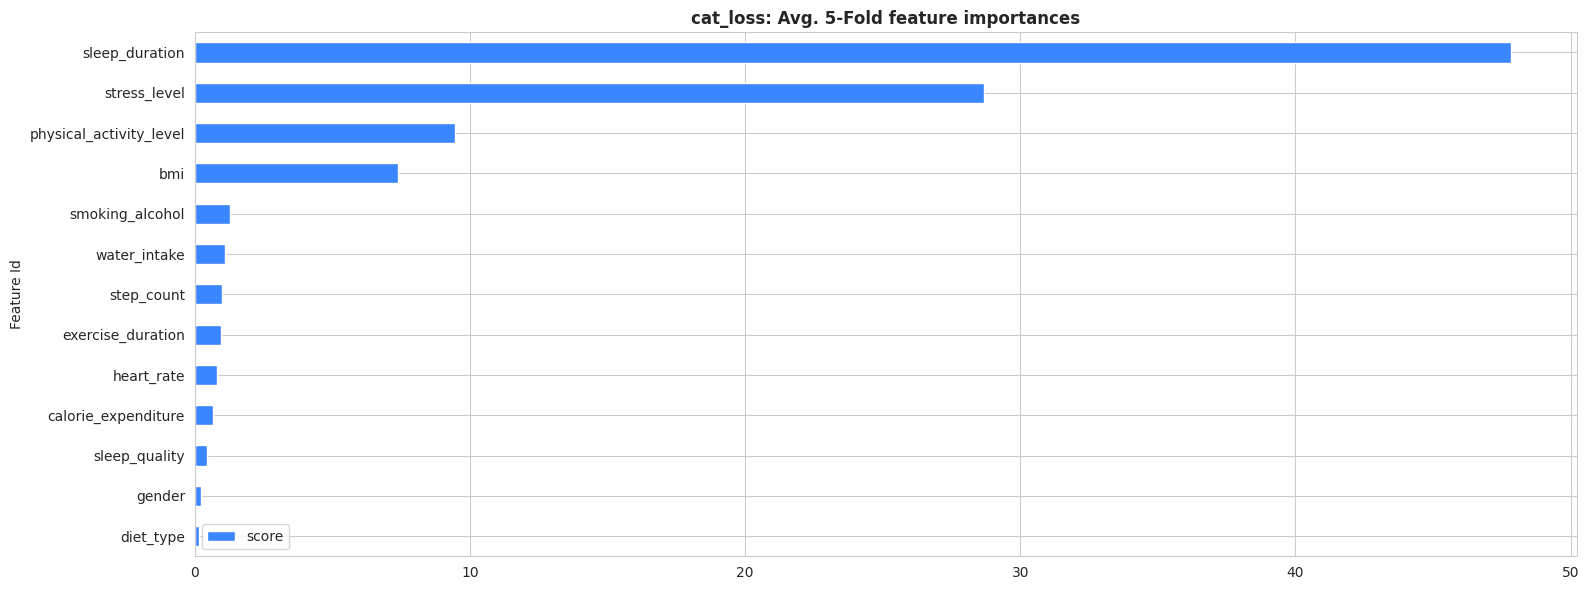

In [54]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            all_feat_importances[k] = y # np.mean(value, axis=0)
        elif x == "val_data":
            all_val_data[k] = y # -> [0] select X_valid, [1] select y_valid

top_n = 20

for i, (m, df) in enumerate(all_feat_importances.items()):
    df_merge = df[0].merge(df[1], how="left", on="Feature Id", suffixes=("_0", ""))\
                    .merge(df[2], how="left", on="Feature Id", suffixes=("_1", ""))\
                    .merge(df[3], how="left", on="Feature Id", suffixes=("_2", ""))\
                    .merge(df[4], how="left", on="Feature Id", suffixes=("_3", "_4"))

    # display(df_merge.head())
    ## -------------------------------------------------------------------------------
    # df_merge["avg_score"] = df_merge.iloc[:, 1:].mean(axis=1)
    # df_merge.sort_values(by="avg_score").iloc[:, :top_n].plot.barh(y="avg_score", x="Feature Id", figsize=(18, 8))
    # plt.tight_layout()
    # plt.show()
    # print()
    ## -------------------------------------------------------------------------------
    df_final = pd.concat([df[0]["Feature Id"], df_merge.drop(columns=["Feature Id"])\
                                                       .mean(axis=1)], axis=1)\
                                                       .rename(columns={0: "score"})\
                                                       .sort_values(by="score")

    ax = df_final.tail(top_n).plot.barh(y="score", x="Feature Id", figsize=(16, 6))
    ax.set_title(f"{m}: Avg. {CFG['FOLDS']}-Fold feature importances", fontweight="semibold")
    plt.tight_layout()
    plt.show()
    print()

In [55]:
# !rm -r /kaggle/working

cat_bayes_94932 saved!


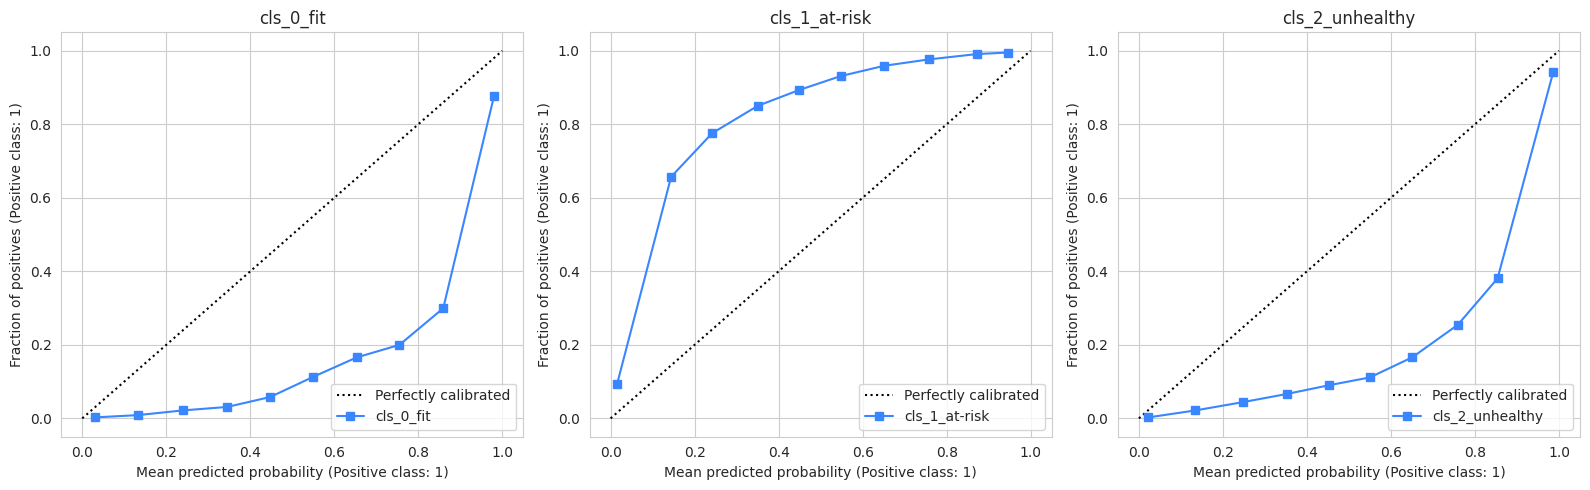

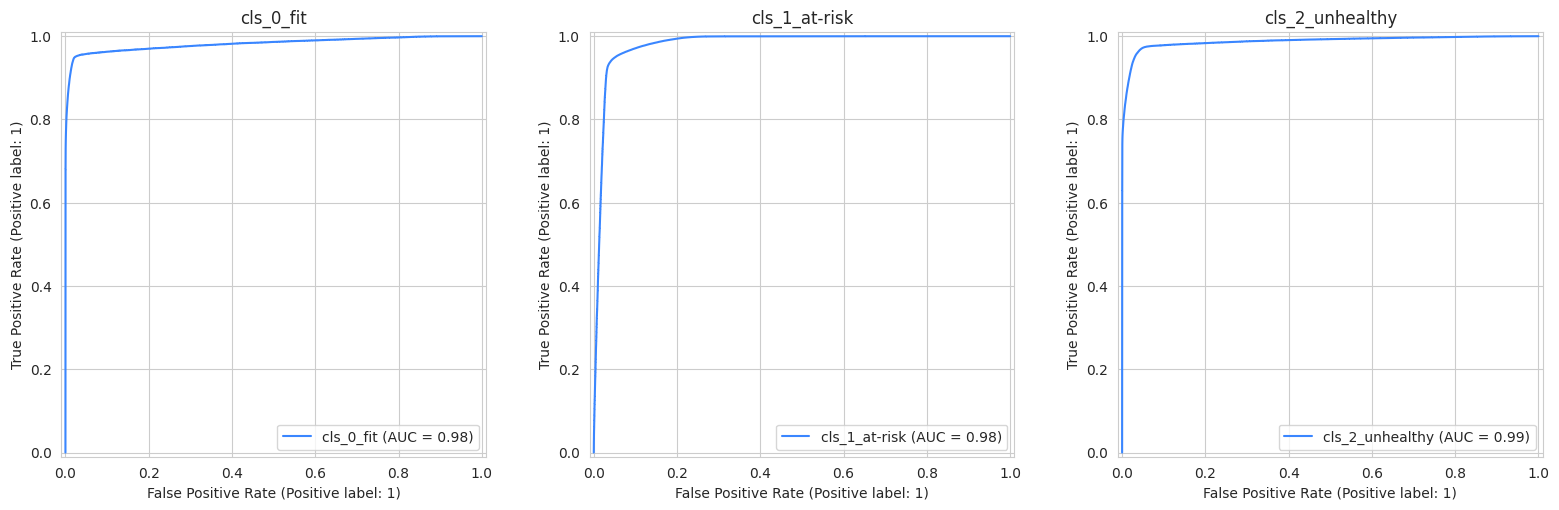


cat_bern_94924 saved!


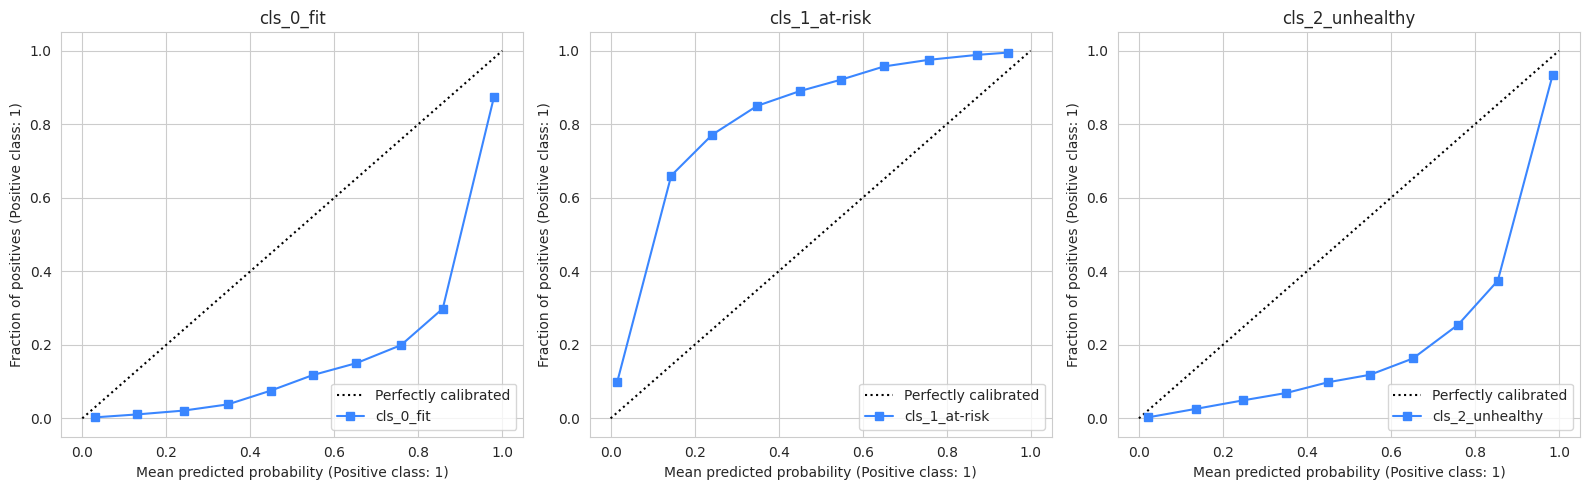

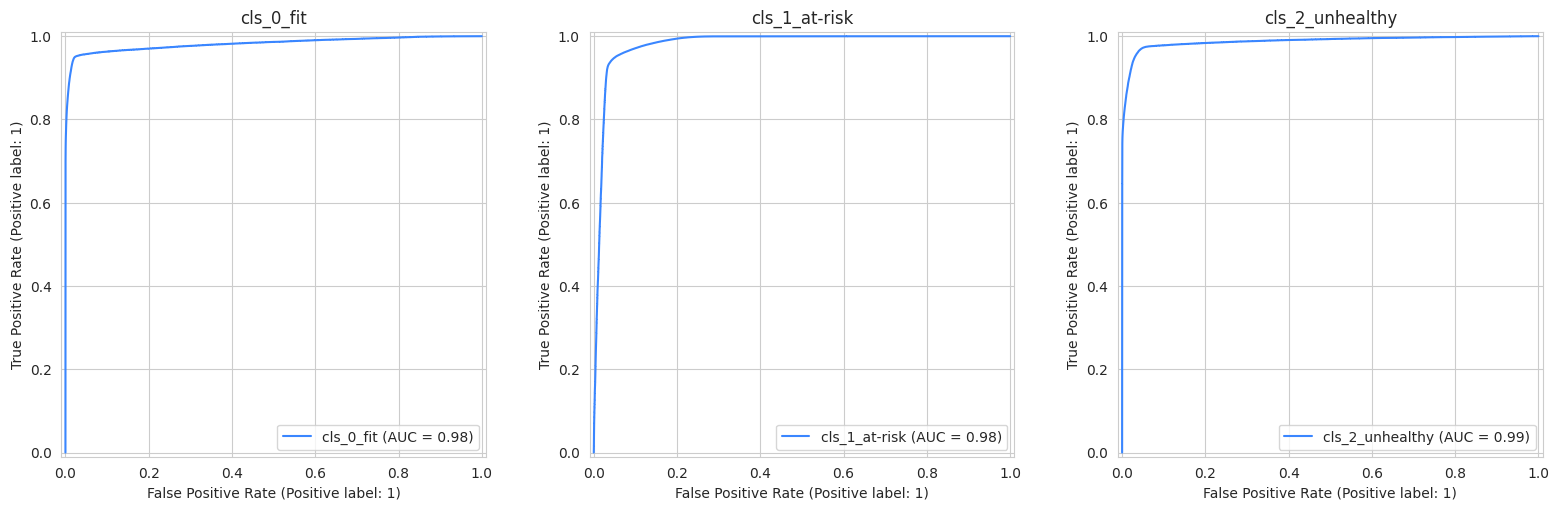


cat_loss_94921 saved!


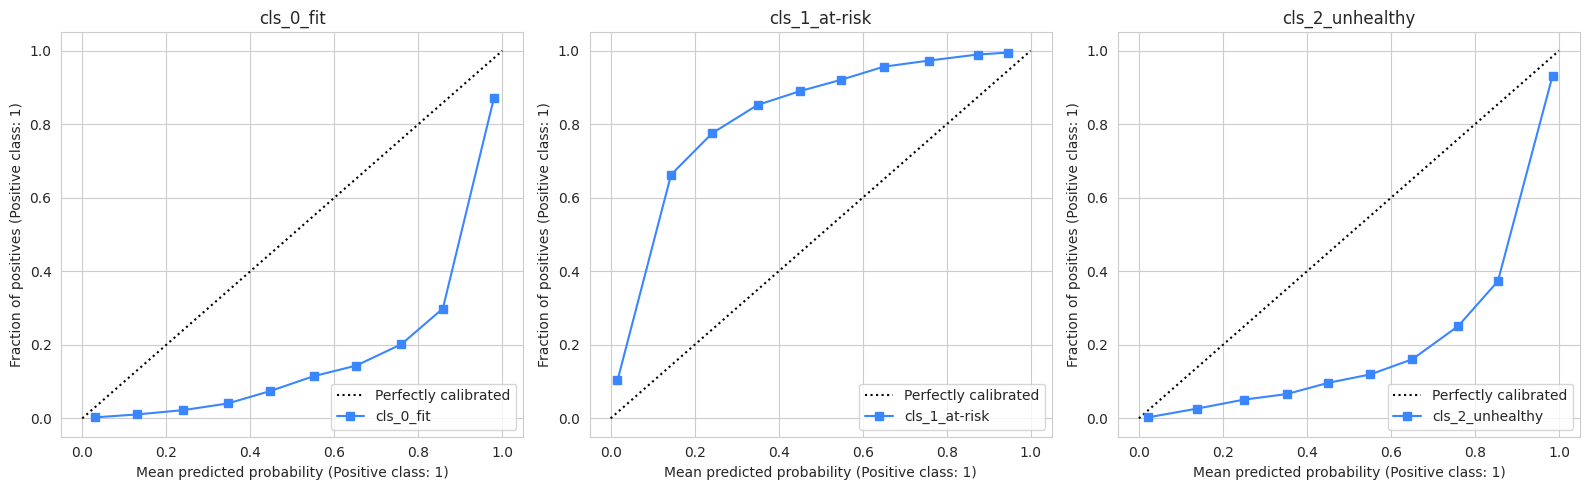

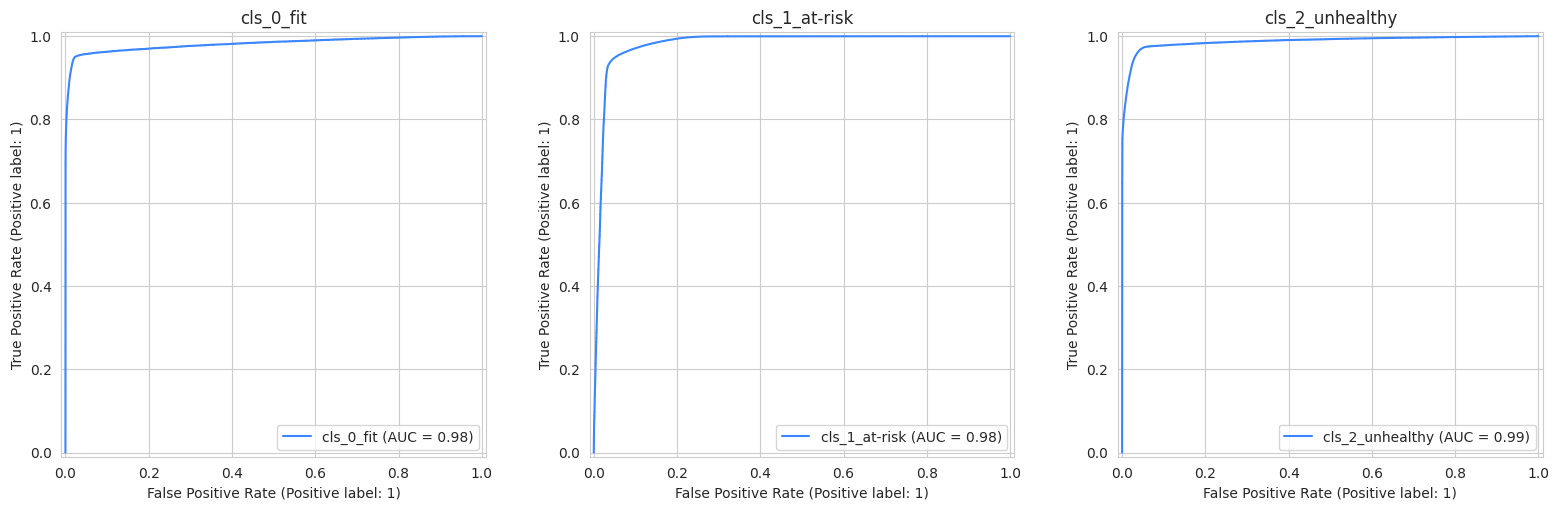

In [56]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            y_labels = pd.Series(np.argmax(y, axis=1))
            classes = [*mapping.keys()]
            name0 = f"cls_0_{classes[0]}"
            name1 = f"cls_1_{classes[1]}"
            name2 = f"cls_2_{classes[2]}"

            y_cls_0 = (train_data[TARGET] == 0).astype(int)
            y_cls_1 = (train_data[TARGET] == 1).astype(int)
            y_cls_2 = (train_data[TARGET] == 2).astype(int)
            p_cls_0 = y[:, 0]
            p_cls_1 = y[:, 1]
            p_cls_2 = y[:, 2]

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            CalibrationDisplay.from_predictions(y_cls_0, p_cls_0, n_bins=10, name=name0, ax=axs[0])
            CalibrationDisplay.from_predictions(y_cls_1, p_cls_1, n_bins=10, name=name1, ax=axs[1])
            CalibrationDisplay.from_predictions(y_cls_2, p_cls_2, n_bins=10, name=name2, ax=axs[2])
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            RocCurveDisplay.from_predictions(
                y_cls_0, p_cls_0, name=name0, ax=axs[0],
                sample_weight=get_sample_weights(y_cls_0, y_cls_0),
            )
            RocCurveDisplay.from_predictions(
                y_cls_1, p_cls_1, name=name1, ax=axs[1],
                sample_weight=get_sample_weights(y_cls_1, y_cls_1),
            )
            RocCurveDisplay.from_predictions(
                y_cls_2, p_cls_2, name=name2, ax=axs[2],
                sample_weight=get_sample_weights(y_cls_2, y_cls_2),
            )
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            print()

cat_bayes_94932 saved! (295753, 3)


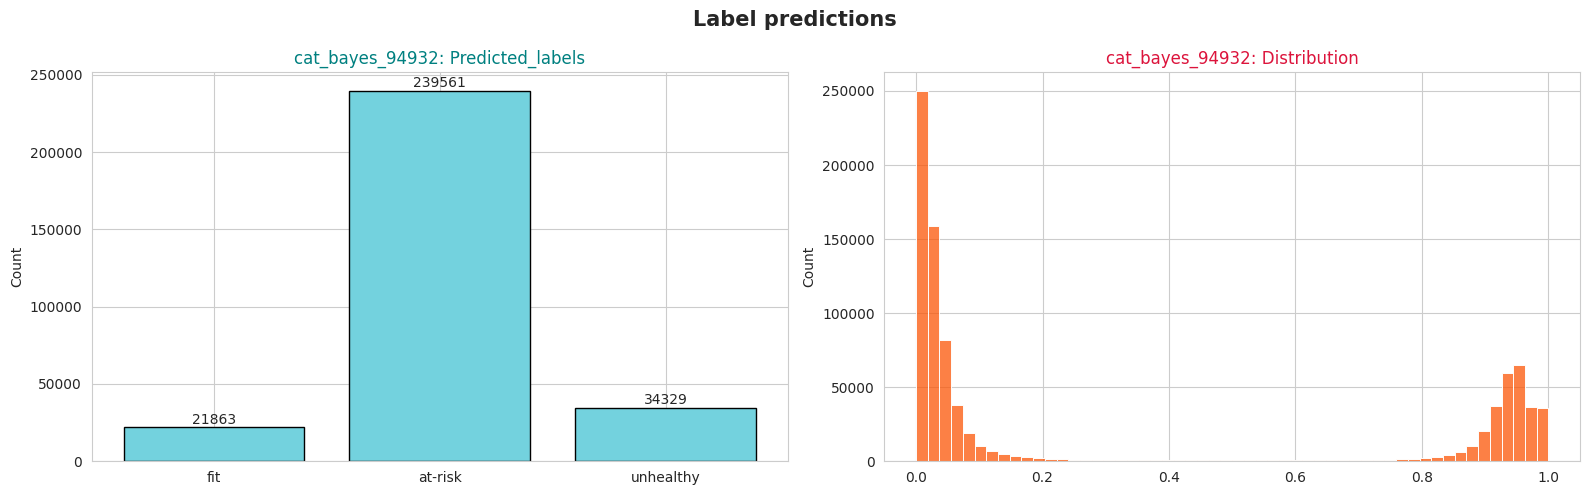


cat_bern_94924 saved! (295753, 3)


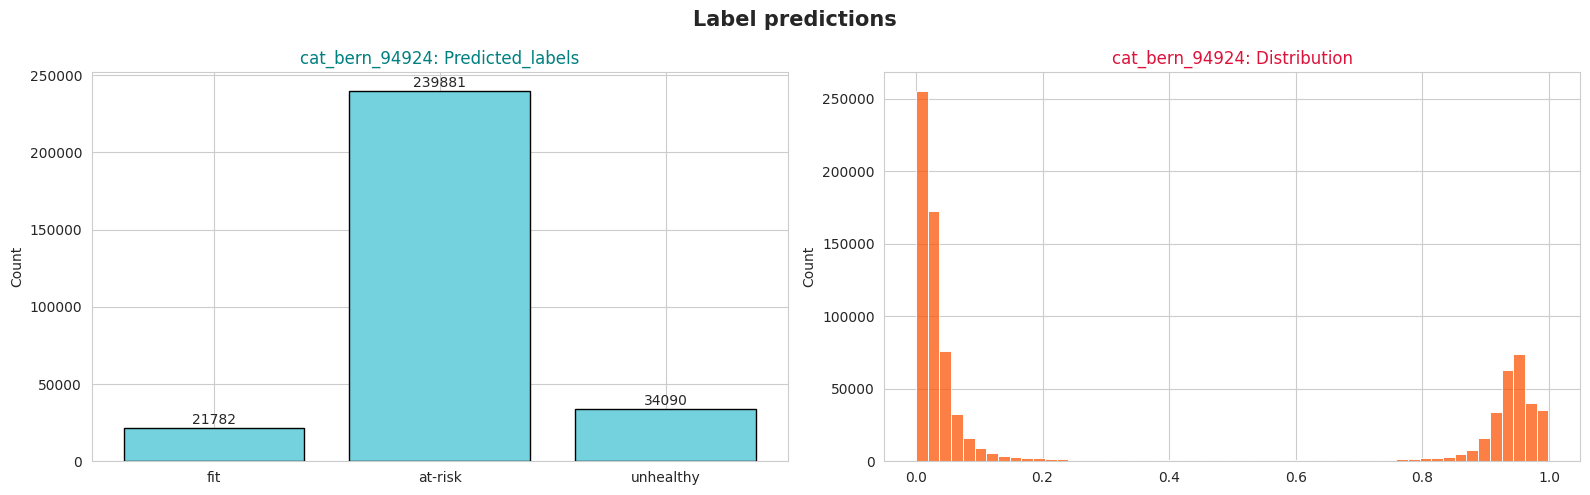


cat_loss_94921 saved! (295753, 3)


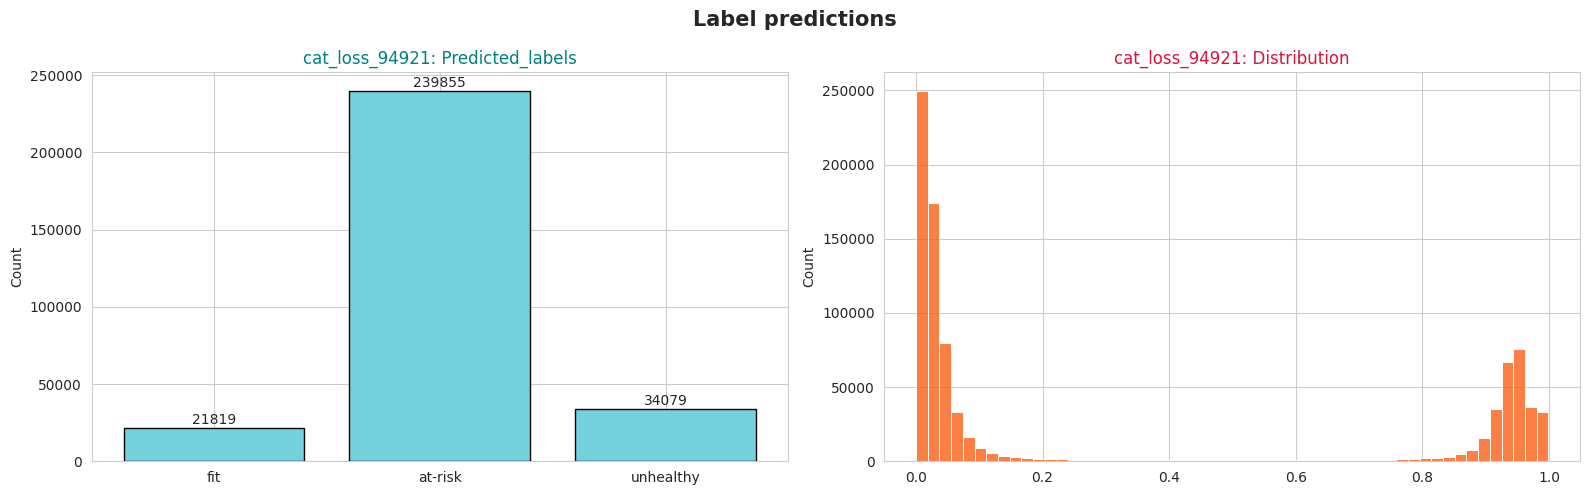

In [57]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"test_{n}_.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(16, 5))

            counts = [np.sum(y_labels == _) for _ in range(len(mapping))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')

            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')

            plt.tight_layout()
            plt.show()

            print()

In [58]:
pd.DataFrame(model_results)

,cat_bayes_94932,cat_bern_94924,cat_loss_94921
0,unhealthy,unhealthy,unhealthy
1,unhealthy,unhealthy,unhealthy
2,at-risk,at-risk,at-risk
3,at-risk,at-risk,at-risk
4,unhealthy,unhealthy,unhealthy
...,...,...,...
295748,fit,fit,fit
295749,at-risk,at-risk,at-risk
295750,unhealthy,unhealthy,unhealthy
295751,at-risk,at-risk,at-risk


In [59]:
# !rm -r /kaggle/working